#MONTH01

In [2]:
#PHASE01

In [3]:
import pandas as pd

dublin_data = {
    'station_name': ['smithfield','parnell Square','clonmel Street','mount Street','Custom House'],
    'Total_Docks':[0,0,0,0,0],
    'Available_Bikes':[0,0,0,0,0],
    'Available_Docks':[0,0,0,0,0],
    'status': ['open', 'open', 'open', 'open', 'Closed']
}

df = pd.DataFrame(dublin_data)
df.head()

,station_name,Total_Docks,Available_Bikes,Available_Docks,status
0,smithfield,0,0,0,open
1,parnell Square,0,0,0,open
2,clonmel Street,0,0,0,open
3,mount Street,0,0,0,open
4,Custom House,0,0,0,Closed


In [4]:
df['Total_Docks'] = [20,30,25,15,40]
df['Available_Bikes'] = [12,18,5,9,0]
df['Available_Docks'] = [8,12,20,6,40]

df.head()

,station_name,Total_Docks,Available_Bikes,Available_Docks,status
0,smithfield,20,12,8,open
1,parnell Square,30,18,12,open
2,clonmel Street,25,5,20,open
3,mount Street,15,9,6,open
4,Custom House,40,0,40,Closed


In [5]:
df.describe()

,Total_Docks,Available_Bikes,Available_Docks
count,5.000000,5.00000,5.000000
mean,26.000000,8.80000,17.200000
std,9.617692,6.83374,13.827509
min,15.000000,0.00000,6.000000
25%,20.000000,5.00000,8.000000
50%,25.000000,9.00000,12.000000
75%,30.000000,12.00000,20.000000
max,40.000000,18.00000,40.000000


In [6]:
open_stations = df[df['status'] == 'open']

open_stations

,station_name,Total_Docks,Available_Bikes,Available_Docks,status
0,smithfield,20,12,8,open
1,parnell Square,30,18,12,open
2,clonmel Street,25,5,20,open
3,mount Street,15,9,6,open


In [7]:
high_bike_stations = df[(df['status'] == 'open') & (df['Available_Bikes'] > 5)]

high_bike_stations

,station_name,Total_Docks,Available_Bikes,Available_Docks,status
0,smithfield,20,12,8,open
1,parnell Square,30,18,12,open
3,mount Street,15,9,6,open


In [8]:
df['Total_Occupied_Docks'] = df['Total_Docks'] - df['Available_Docks']

df['Bike_Availability_Rate'] = (df['Available_Bikes'] / df['Total_Docks']) * 100

df

,station_name,Total_Docks,Available_Bikes,Available_Docks,status,Total_Occupied_Docks,Bike_Availability_Rate
0,smithfield,20,12,8,open,12,60.0
1,parnell Square,30,18,12,open,18,60.0
2,clonmel Street,25,5,20,open,5,20.0
3,mount Street,15,9,6,open,9,60.0
4,Custom House,40,0,40,Closed,0,0.0


In [9]:
#PHASE 02

In [10]:
import numpy as np #numpy library ko call kiya missing value banane ke liye
import pandas as pd

#dublin ka new data jisme kuch khali jagah (np.nan) hai
dublin_dirty_data = {
    'station_Name': ['Smithfield','Parnell Square','Clonmel Street','Mount Street','Custom House'],
    'Total_Docks': [31, np.nan, 21,20, np.nan], #2 jagah data gayab hai
    'Available_Bikes': [9,0, np.nan, 5,0],   # ek jagah data gayab hai
    'Status': ['Open','Open','Open','Open','Closed']
}

#dataframe banana
df_dirty = pd.DataFrame(dublin_dirty_data)

#table dekhne ke liye
df_dirty

,station_Name,Total_Docks,Available_Bikes,Status
0,Smithfield,31.0,9.0,Open
1,Parnell Square,NaN,0.0,Open
2,Clonmel Street,21.0,NaN,Open
3,Mount Street,20.0,5.0,Open
4,Custom House,NaN,0.0,Closed


In [11]:
#har column me total kitni khali(NaN) jagah hai,unki counting karna

df_dirty.isnull().sum()

station_Name       0
Total_Docks        2
Available_Bikes    1
Status             0
dtype: int64

In [12]:
df_clean_rows = df_dirty.dropna()  # un rows ko remove karna jaha koi bhi values (NaN) hai.

#clean ki hui values ko dekhna
df_clean_rows

,station_Name,Total_Docks,Available_Bikes,Status
0,Smithfield,31.0,9.0,Open
3,Mount Street,20.0,5.0,Open


In [13]:
df_clean_cols = df_dirty.dropna(axis=1)  #un columns ko remove kiya jinme values missing hai (NaN) hai.(axis=1 matlab column)


#output dekhna
df_clean_cols

,station_Name,Status
0,Smithfield,Open
1,Parnell Square,Open
2,Clonmel Street,Open
3,Mount Street,Open
4,Custom House,Closed


In [14]:
#fillna = bina koi bhi record rows ya column delete kiye unke khali space ko mean ya median se fill karna

In [15]:
total_docks_mean = df_dirty['Total_Docks'].mean()  #Total_Docks ka mean nikalna


#Total_Docks ki khali space ko us mean se fill kiya
df_dirty["Total_Docks"] = df_dirty['Total_Docks'].fillna(total_docks_mean)


#table check kiya
df_dirty

,station_Name,Total_Docks,Available_Bikes,Status
0,Smithfield,31.0,9.0,Open
1,Parnell Square,24.0,0.0,Open
2,Clonmel Street,21.0,NaN,Open
3,Mount Street,20.0,5.0,Open
4,Custom House,24.0,0.0,Closed


In [16]:
bikes_median = df_dirty['Available_Bikes'].median()  #Available_Bikes ka median nikala


#Available_Bikes ki khali space ko median se fill kiya
df_dirty['Available_Bikes'] = df_dirty['Available_Bikes'].fillna(bikes_median)


#final clean table dekhi
df_dirty

,station_Name,Total_Docks,Available_Bikes,Status
0,Smithfield,31.0,9.0,Open
1,Parnell Square,24.0,0.0,Open
2,Clonmel Street,21.0,2.5,Open
3,Mount Street,20.0,5.0,Open
4,Custom House,24.0,0.0,Closed


In [17]:
open_status = df_dirty[(df_dirty["Status"] == 'Open')  &  (df_dirty["Total_Docks"]> 20)] #jo status open hai or total docks 20 se jyada hai

open_status

,station_Name,Total_Docks,Available_Bikes,Status
0,Smithfield,31.0,9.0,Open
1,Parnell Square,24.0,0.0,Open
2,Clonmel Street,21.0,2.5,Open


In [18]:
df_dirty.loc[df_dirty['station_Name'] == 'Custom House','Available_Bikes'] = np.nan

df_dirty

,station_Name,Total_Docks,Available_Bikes,Status
0,Smithfield,31.0,9.0,Open
1,Parnell Square,24.0,0.0,Open
2,Clonmel Street,21.0,2.5,Open
3,Mount Street,20.0,5.0,Open
4,Custom House,24.0,NaN,Closed


In [19]:
#agar status == 'Closed' hai to 0 bharo Availabe_Bikes column me,nahi to purani value hai to wahi rehne do
df_dirty['Available_Bikes'] = np.where(
    df_dirty['Status'] == 'Closed',
    0,
    df_dirty['Available_Bikes']
)

df_dirty

,station_Name,Total_Docks,Available_Bikes,Status
0,Smithfield,31.0,9.0,Open
1,Parnell Square,24.0,0.0,Open
2,Clonmel Street,21.0,2.5,Open
3,Mount Street,20.0,5.0,Open
4,Custom House,24.0,0.0,Closed


In [20]:
#table ke sabhi columns ke datatype check karna
df_dirty.dtypes

station_Name        object
Total_Docks        float64
Available_Bikes    float64
Status              object
dtype: object

In [21]:
#'Total_Docks' or 'Available_Bikes' ko float se int me badalna
df_dirty['Total_Docks'] = df_dirty['Total_Docks'].astype(int)
df_dirty['Available_Bikes'] = df_dirty['Available_Bikes'].astype(int)


#final clean table or uske data ko dobara  dekhna
print(df_dirty.dtypes)
df_dirty

station_Name       object
Total_Docks         int32
Available_Bikes     int32
Status             object
dtype: object


,station_Name,Total_Docks,Available_Bikes,Status
0,Smithfield,31,9,Open
1,Parnell Square,24,0,Open
2,Clonmel Street,21,2,Open
3,Mount Street,20,5,Open
4,Custom House,24,0,Closed


In [22]:
#MONTH02

In [23]:
#PHASE03

In [24]:
#SQL3 library ko call kiya
import sqlite3

#database se connection banana(agar file nahi hai,to yeh apne aap ek file bana dega)
conn = sqlite3.connect("Dublin_Smart_Transit.db")

#database se connection chalane ke liye ek cursor banana.
cursor = conn.cursor()

print("SQL Database connected successfully!")

SQL Database connected successfully!


In [25]:
#SQL query likhna: agar table pehle se bani hai,to 'dublin_transit_table' naam ki table banao.
create_table_query = """
CREATE TABLE IF NOT EXISTS dublin_transit_table(
     Station_Name TEXT,
     Total_Docks INTEGER,
     Available_Bikes INTEGER,
     Status TEXT
);
"""

#is query ko database ke andar run(execute) karna
cursor.execute(create_table_query)

#changes ko database me permanently save(Commit) karna
conn.commit()


print("Table structure created in SQL successfully!")

Table structure created in SQL successfully!


In [26]:
#Pandas dataframe ko seedhe SQL table me export karna.
#name = hamari SQL table ka naaam, con = hamara active database connection.
#if_exists = 'append' ka matlab hai structure bana hua hai, data uske niche jod do.
df_dirty.to_sql(name='dublin_transit_table', con=conn, if_exists='append', index=False)

print("Data from Pandas exported to SQL Table successfully!")

Data from Pandas exported to SQL Table successfully!


In [27]:
#SQL query chalakar dekhna ki table me kya data aaya hai.
cursor.execute("SELECT * FROM dublin_transit_table;")

#cursor dwara nikale gye sabhi records ko kichkar(fetch) lana.
sql_rows = cursor.fetchall()

#sabhi rows ko ek ek karke print karna
for row in sql_rows:
    print(row)

('Smithfield', 31, 9, 'Open')
('Parnell Square', 24, 0, 'Open')
('Clonmel Street', 21, 2, 'Open')
('Mount Street', 20, 5, 'Open')
('Custom House', 24, 0, 'Closed')
('Smithfield', 31, 9, 'Open')
('Parnell Square', 24, 0, 'Open')
('Clonmel Street', 21, 2, 'Open')
('Mount Street', 20, 5, 'Open')
('Custom House', 24, 0, 'Closed')


In [28]:
# AGAR DATA EK SE JYADA BAAR PRINT HOKAR AA RAHA HAI TO YE NICHE WALA CODE KARE, it is called 'DATA DUPLICATION'.

In [29]:
#purani duplictae table ko puri tarah se delete(drop) karna
cursor.execute("DROP TABLE IF EXISTS dublin_transit_table;")
conn.commit()

#dobara new fresh table load karna('replace')
df_dirty.to_sql(name='dublin_transit_table',con=conn,if_exists='replace',index=False)


#ab check kare ki , ki sirf 5 records print honge na ki ek hi record baar baar print hoga
cursor.execute("SELECT*FROM dublin_transit_table;") #cursor ek jariya hai python program se baat karne ka, or execute cursor ke command deta hai ki bracket ke andar likhi hui command ko run kare.
for row in cursor.fetchall():  #jab SELECT QUERY chalate hai to jo data python se aaiga usko us sare data ko ye list me daal deta hai or har list ek row yani tuple ke roop me aati hai
    print(row)

('Smithfield', 31, 9, 'Open')
('Parnell Square', 24, 0, 'Open')
('Clonmel Street', 21, 2, 'Open')
('Mount Street', 20, 5, 'Open')
('Custom House', 24, 0, 'Closed')


In [30]:
#pure SQL query likhna (sirf Open stations ke liye)
query_open = "SELECT * FROM dublin_transit_table WHERE Status = 'Open';"

#is query ko cursor ke through database me run karna 
cursor.execute(query_open)

#filter kiye hue sabhi records ko fetch karna 
open_rows = cursor.fetchall()

#result ko screen per print karke dekhna
print("--- Only Open Stations from SQL ---")
for row in open_rows:
    print(row)

--- Only Open Stations from SQL ---
('Smithfield', 31, 9, 'Open')
('Parnell Square', 24, 0, 'Open')
('Clonmel Street', 21, 2, 'Open')
('Mount Street', 20, 5, 'Open')


In [31]:
#SQL me 2 conditions lagane ke liye AND keyword ka use karna
query_advanced = """
SELECT Station_Name, Available_Bikes
FROM dublin_transit_table
WHERE Status = 'Open' AND Available_Bikes > 5;
"""

#query run karna or data fetch karna
cursor.execute(query_advanced)
advanced_rows = cursor.fetchall()


print("\n--- Open Stations with Bikes > 5 ---")
for row in advanced_rows:
    print(row)


--- Open Stations with Bikes > 5 ---
('Smithfield', 9)


In [32]:
#GROUP BY or SUM ka use karke pure SQL query likhi
query_groupby = """
SELECT Status, SUM(Available_Bikes) AS Total_Bikes
FROM dublin_transit_table
GROUP BY Status;
"""

#is query ko cursor ke through run karna
cursor.execute(query_groupby)

#Aggregate kiye hue records ko fetch karna
summary_rows = cursor.fetchall()

#result ko screen per print karke dekhna 
print("---Total Available Bikes by Station Status ---")
for row in summary_rows:
     print(f"Status: {row[0]} | Total Bikes Available: {row[1]}")

---Total Available Bikes by Station Status ---
Status: Closed | Total Bikes Available: 0
Status: Open | Total Bikes Available: 16


In [33]:
#COUNT or AVG aggregate function ka ek sath use karna
query_avg = """
SELECT Status, COUNT(Station_Name) AS Total_Stations, AVG(Total_Docks) AS Avg_Docks
FROM dublin_transit_table
GROUP BY Status;
"""

#query run karna or data fectch karna
cursor.execute(query_avg)
avg_rows = cursor.fetchall()

print("
--- Station Count & Average Docks by Status ---")
for row in avg_rows:
    print(f"Status: {row[0]} | Stations: {row[1]} Avg Docks: {row[2]:.2f}")

/n--- Station Count & Average Docks by Status ---
Status: Closed | Stations: 1 Avg Docks: 24.00
Status: Open | Stations: 4 Avg Docks: 24.00


In [34]:
import pandas as pd

# weather ka ek new dataFrame banaya
weather_data = {
    "station_Name": ['Smithfield', 'Parnell Square', 'Clonmel Street', 'Mount Street', 'St. Stephen\'s Green'],
    'Temperature_C': [15,18,20,16,17],
    'Weather_Condition': ['Rainy', 'Cloudy', 'Rainy', 'Sunny', 'Windy']
}
df_weather = pd.DataFrame(weather_data)

#weather ki table dekhna
print("---Weather Data Table---")
print(df_weather)


---Weather Data Table---
          station_Name  Temperature_C Weather_Condition
0           Smithfield             15             Rainy
1       Parnell Square             18            Cloudy
2       Clonmel Street             20             Rainy
3         Mount Street             16             Sunny
4  St. Stephen's Green             17             Windy


In [35]:
df_weather  #new table weather ki

,station_Name,Temperature_C,Weather_Condition
0,Smithfield,15,Rainy
1,Parnell Square,18,Cloudy
2,Clonmel Street,20,Rainy
3,Mount Street,16,Sunny
4,St. Stephen's Green,17,Windy


In [36]:
df_dirty #pehle wali table jo pehle banai thi

,station_Name,Total_Docks,Available_Bikes,Status
0,Smithfield,31,9,Open
1,Parnell Square,24,0,Open
2,Clonmel Street,21,2,Open
3,Mount Street,20,5,Open
4,Custom House,24,0,Closed


In [37]:
#pd.merge function ke help se dono dataframe ke data ko  merge kiya
df_merged = pd.merge(df_dirty,df_weather, on = 'station_Name', how='inner')

#
print("---Final Merged Data Table---")
df_merged

---Final Merged Data Table---


,station_Name,Total_Docks,Available_Bikes,Status,Temperature_C,Weather_Condition
0,Smithfield,31,9,Open,15,Rainy
1,Parnell Square,24,0,Open,18,Cloudy
2,Clonmel Street,21,2,Open,20,Rainy
3,Mount Street,20,5,Open,16,Sunny


In [38]:
#PHASE 04 

In [39]:
#request library ko import kiya jo internet se data fetch karti hai
import requests
import pandas as pd

#dublin city ka live goverment API url 
api_url = "https://api.cyclocity.fr/contracts/dublin/gbfs/station_status.json"

#server ko request send karna or live data response prapt karna
response = requests.get(api_url)

#check kiya ki kya internet connection successful raha(HTTP Status 200 = Success)

print(f"API Connection Status Code: {response.status_code}")

API Connection Status Code: 200


In [40]:
#data ko json format me load karna
if response.status_code == 200:  
    live_data = response.json()   #yeh server se mile text/data ko python  ke dictionory format me covert kar deta hai taki easuly data access ho sake, isme live_data variable me store kiya hai
    print("Master Data Keys:",live_data.keys())   #ye dictionary ki sari main keys jo top level par hai unko print kar dega
    print("\n--- Success! Real Live Record Fetched ---")
    
    #pehla live station record dekhna
    print(live_data['data']['stations'][0])  #poore data me se ek specific station ki sari information dega, is code me live_data ek data box hai, 'data' is main box ke andar ek key hai jiska naam 'data' hai. hum iske andar gye.
else:                                        #'data' ke andar ek or list hai jiska naam 'stations' hai(isme bahut sari lists hai) ,or [0] yeh index hai matlab pehla station(first item).
    
    print("Connection failed, check internet!")

Master Data Keys: dict_keys(['last_updated', 'ttl', 'version', 'data'])

--- Success! Real Live Record Fetched ---
{'station_id': '1', 'num_bikes_available': 22, 'vehicle_types_available': [{'vehicle_type_id': 'mechanical', 'count': 17}, {'vehicle_type_id': 'electrical', 'count': 5}], 'num_bikes_disabled': 0, 'num_docks_available': 9, 'num_docks_disabled': 0, 'is_installed': True, 'is_renting': False, 'is_returning': True, 'last_reported': 1786672977}


In [41]:
#pandas ke advance json_normalize function ka use karke live data ko table me convert kiya
df_live = pd.json_normalize(live_data['data']['stations'])


#live bani hui new table ki pehli 5 rows dekhi
df_live.head()

,station_id,num_bikes_available,vehicle_types_available,num_bikes_disabled,num_docks_available,num_docks_disabled,is_installed,is_renting,is_returning,last_reported
0,1,22,"[{'vehicle_type_id': 'mechanical', 'count': 17...",0,9,0,True,False,True,1786672977
1,2,2,"[{'vehicle_type_id': 'mechanical', 'count': 2}...",0,17,0,True,False,True,1786730705
2,3,7,"[{'vehicle_type_id': 'mechanical', 'count': 4}...",0,13,0,True,False,True,1786727777
3,4,11,"[{'vehicle_type_id': 'mechanical', 'count': 10...",0,9,0,True,False,True,1786672977
4,5,23,"[{'vehicle_type_id': 'mechanical', 'count': 12...",0,17,0,True,False,True,1786672971


In [42]:
#table ka shape (Rows,Cloumns) check karna.
print(f"Total Stations Fetched Live: {df_live.shape}") # string ke starting me f lagane se curly{} ke andar kisi bhi varible ya expression ka naaam likh sakte hai or code run hote hi {} ke andar wali value ko uski actual value ke sath evaluate karke replace kar deta hai.

Total Stations Fetched Live: (116, 10)


In [43]:
#'last_reported' timestamp ko asli Date-Time format me change karna
df_live['Reported_Time'] = pd.to_datetime(df_live['last_reported'], unit='s')

#new column ko check karne ke liye keval station ka naam or change hua time dekhna
df_live[['station_id', 'Reported_Time']].head()

,station_id,Reported_Time
0,1,2026-08-14 02:02:57
1,2,2026-08-14 18:05:05
2,3,2026-08-14 17:16:17
3,4,2026-08-14 02:02:57
4,5,2026-08-14 02:02:51


In [44]:
#time ko dublin(Europe/Dublin) ke local Timezone me set(localized) karna
df_live['Reported_Time'] = df_live['Reported_Time'].dt.tz_localize('UTC').dt.tz_convert('Europe/Dublin')

#last converted time ko dekhna
df_live[['station_id', 'Reported_Time']].head()

,station_id,Reported_Time
0,1,2026-08-14 03:02:57+01:00
1,2,2026-08-14 19:05:05+01:00
2,3,2026-08-14 18:16:17+01:00
3,4,2026-08-14 03:02:57+01:00
4,5,2026-08-14 03:02:51+01:00


In [45]:
#1.Time me se hour nikalna(0 se 23 ke beech ka number)
df_live['Hour'] = df_live['Reported_Time'].dt.hour

#2. week ka kon sa din hai(Day of Week) nikalna (0=Monday, 6=Sunday)
df_live['Day_of_Week'] = df_live['Reported_Time'].dt.dayofweek

#3. year ka kon sa month hai ye nikalna (1 se 12 ke beech ka number)
df_live['Month'] = df_live['Reported_Time'].dt.month

#4.New columns ke sath data ko dekhna
df_live[['station_id', 'Reported_Time', 'Hour', 'Day_of_Week', 'Month']].head()

,station_id,Reported_Time,Hour,Day_of_Week,Month
0,1,2026-08-14 03:02:57+01:00,3,4,8
1,2,2026-08-14 19:05:05+01:00,19,4,8
2,3,2026-08-14 18:16:17+01:00,18,4,8
3,4,2026-08-14 03:02:57+01:00,3,4,8
4,5,2026-08-14 03:02:51+01:00,3,4,8


In [46]:
#1. poori table ko ek master CSV file me export karna
#2. index_False ka matlab hai ki faltu ke serial number(0,1,2) file me save na ho.
df_live.to_csv("Dublin_Live_Transit_Master.csv", index=False)

print("Master Live Transit Dataset exported to CSV successfully!")
print("Database Architecture & Data Engineering Phases: 100% COMPLETE!")

Master Live Transit Dataset exported to CSV successfully!
Database Architecture & Data Engineering Phases: 100% COMPLETE!


In [47]:
# save ki hui master file ko wapas load karke check karna. 
df_master_check = pd.read_csv("Dublin_Live_Transit_Master.csv")

#iski pehli 3 lines dekhna.
df_master_check.head(3)

,station_id,num_bikes_available,vehicle_types_available,num_bikes_disabled,num_docks_available,num_docks_disabled,is_installed,is_renting,is_returning,last_reported,Reported_Time,Hour,Day_of_Week,Month
0,1,22,"[{'vehicle_type_id': 'mechanical', 'count': 17...",0,9,0,True,False,True,1786672977,2026-08-14 03:02:57+01:00,3,4,8
1,2,2,"[{'vehicle_type_id': 'mechanical', 'count': 2}...",0,17,0,True,False,True,1786730705,2026-08-14 19:05:05+01:00,19,4,8
2,3,7,"[{'vehicle_type_id': 'mechanical', 'count': 4}...",0,13,0,True,False,True,1786727777,2026-08-14 18:16:17+01:00,18,4,8


In [48]:
#MONTH 03

In [49]:
#Phase 05

In [50]:
# Data visualization ke liye main libraries ko import karna.
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# hamari save ki hui master live transit file ko load karna.
df_master = pd.read_csv("Dublin_Live_Transit_Master.csv")

print("Libraries imported and Master Data loaded successfully!")

Libraries imported and Master Data loaded successfully!


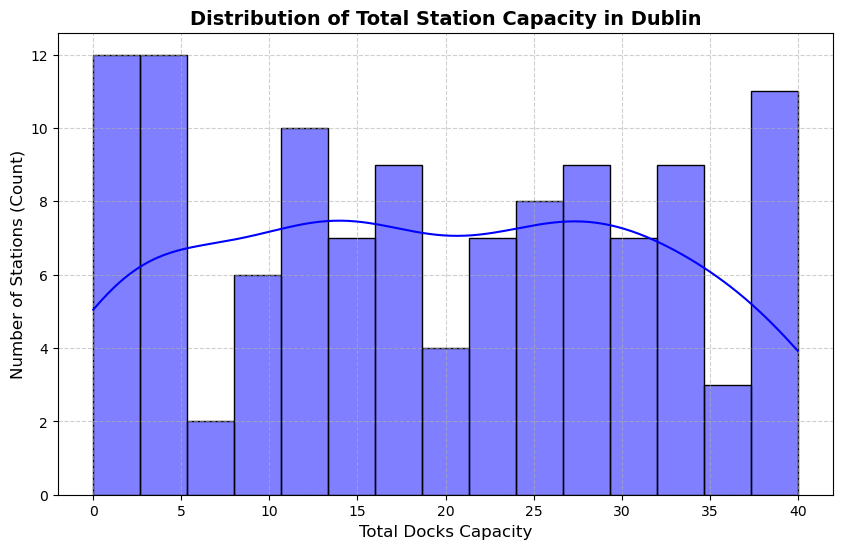

In [51]:
# chart ka size (Width=10, Height=6) fix karna.
plt.figure(figsize=(10,6))

# Seaborn ka use karke Hist or KDE (line) ek sath plot chalana
# x = hamara target column , kde=True se data ka Skewness(jhukav) pata cahlta hai.
sns.histplot(data=df_master, x='num_docks_available', kde=True, color='blue', bins=15)

#chart ko sundar title or tables lagana
plt.title("Distribution of Total Station Capacity in Dublin", fontsize=14, fontweight='bold')
plt.xlabel("Total Docks Capacity", fontsize=12)
plt.ylabel("Number of Stations (Count)", fontsize=12)

#background me grid lines dikhana (taki chart ko read karna easy ho)
plt.grid(True, linestyle='--', alpha=0.6)

# chart ko screen per display karna
plt.show()

In [52]:
# har ghante ke according available bikes ka Mean nikalna.
hourly_bikes = df_master.groupby('Hour')['num_bikes_available'].mean().reset_index()

print("Hourly averages calculated successfully! Ready to plot.")

Hourly averages calculated successfully! Ready to plot.


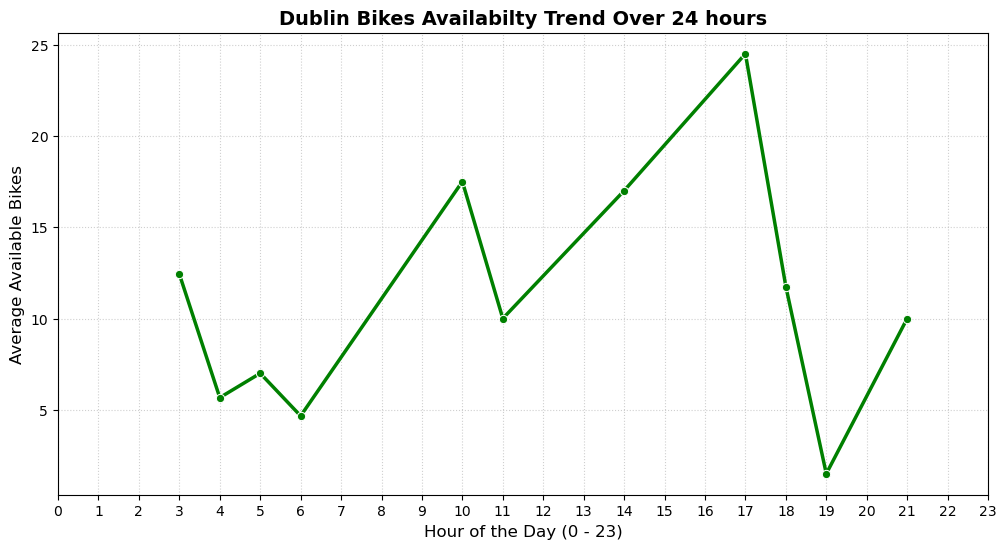

In [53]:
#chart ka size fix karna
plt.figure(figsize=(12,6))

#Seaborn ka use karke line chart banana(x per hours or y per average bikes)
sns.lineplot(data=hourly_bikes, x='Hour', y='num_bikes_available', marker='o', color='green', linewidth=2.5)

#x-axis per 0 se 23 tak ke sabhi hours dikhana (taki chart read karna easy ho)
plt.xticks(range(0,24))

#chart per title, tables, or grid lagana
plt.title("Dublin Bikes Availabilty Trend Over 24 hours", fontsize=14, fontweight='bold')
plt.xlabel("Hour of the Day (0 - 23)", fontsize=12)
plt.ylabel("Average Available Bikes", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)


#chart ko screen per dekhna
plt.show()

In [54]:
#DataFrame me se keval numbers column ko seperate karna.
numeric_df = df_master.select_dtypes(include=['number'])

# in columns ke bich pairwise correlation matrix ki calculation karna.
corr_matrix = numeric_df.corr()

print("Coorelation matrix claculated perfectly! Ready to plot heatmap.")

Coorelation matrix claculated perfectly! Ready to plot heatmap.


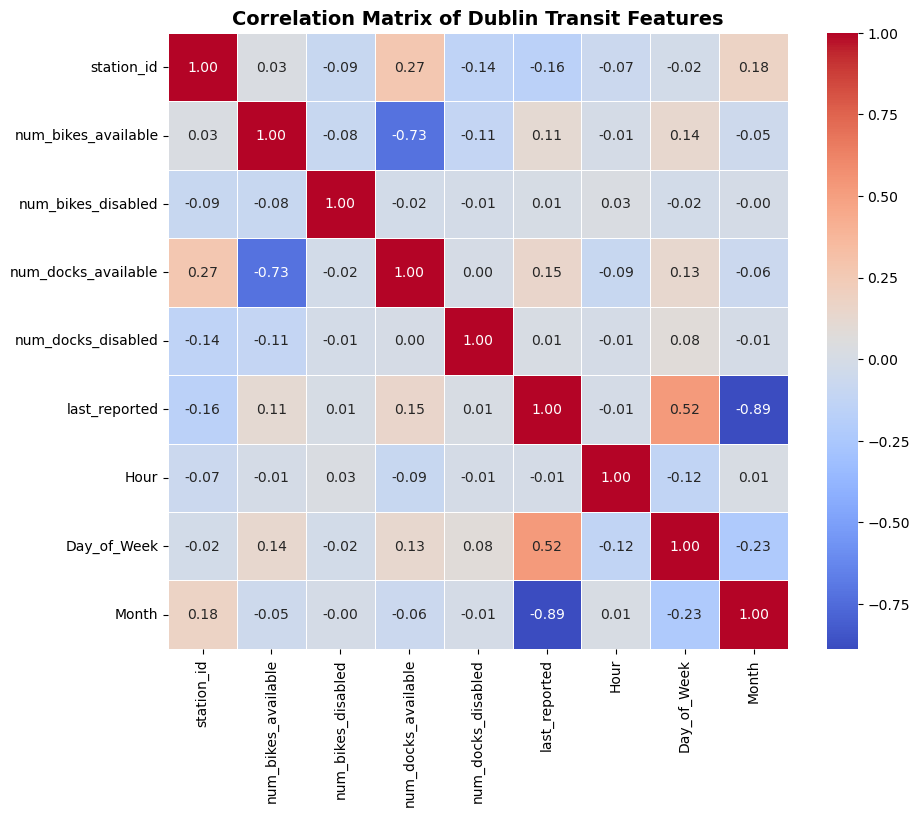

In [55]:
#chart ka canvas size (Width=10, height=8) fix karna.
plt.figure(figsize=(10 , 8))

#Seaborn ka use karke heatmap banana.
#annot=True se blocks ke andar numbers bhi dikhenge , cmap se color theme set hoti hai.
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

# chart per Title likhna.
plt.title("Correlation Matrix of Dublin Transit Features", fontsize=14, fontweight='bold')

#chart ko screen per display karna.
plt.show()

In [56]:
#har do same column ke insect per aane wali value ko evaluate karnege.
#dark red (+1.0 ke pass) iska matlab srtong positive connection hai, agar ek column ki value increase hui to dusre wale ki bhi hogi. jaise ki-
#Digonal par har jagah dark red(1.00) bana hai kyuki har column khud ke sath hamesha match karega hi.

#Drak blue(-1.00 ke paas) iska matlab strong negative connection. agar ek column ki value increase hui to doosre ki decrease hogi. jaise ki-
#num_bikes_availabe or num_docks_availabe ke milne wale box per -0.75(blue color) hai. iska matlab clear hai: agar station par available bikes jyada hogi, to khali docks kam hongi.
#white/light color(0.0 ke paas) iska matlab un dono columns ke aapas me koi khaas relation nahi hai.



C:\Users\rajat\AppData\Local\Temp\ipykernel_9660\4068254952.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_master, x='is_renting', palette='Set2')


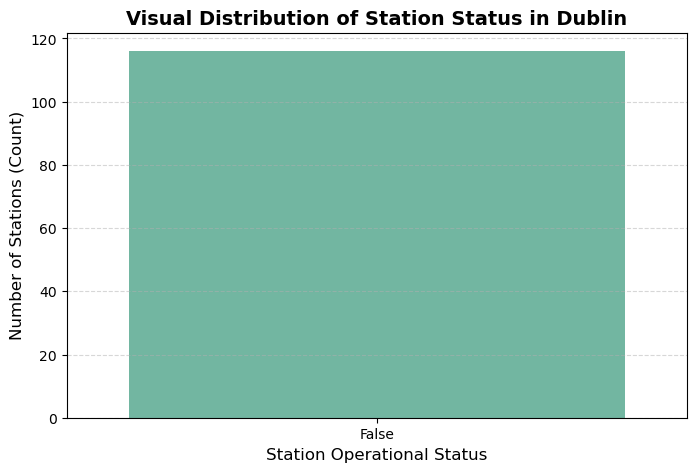

In [57]:
#chart ka canvas size (width=8, height=5) fix kiya.
plt.figure(figsize=(8,5))

# Seaborn ka use karke categorical count plot create karna
# x = hamara column, palette se har baar ka color theme fix karna.
sns.countplot(data=df_master, x='is_renting', palette='Set2')


# charts title or tables lagana
plt.title("Visual Distribution of Station Status in Dublin", fontsize=14, fontweight='bold')
plt.xlabel("Station Operational Status", fontsize=12)
plt.ylabel("Number of Stations (Count)", fontsize=12)

# background me halki grid lines show karna
plt.grid(axis='y', linestyle='--', alpha=0.5)

# chart ko screen per shoe=w karna
plt.show()

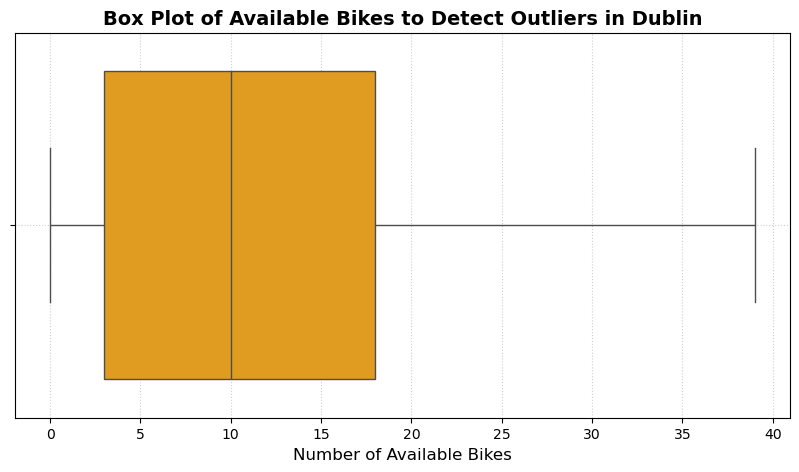

In [58]:
# chart ka canvas size (width=10, height=5) fix karna
plt.figure(figsize=(10,5))

# seaborn ka use karke horizontal box plot banana.
# x= hamara numerical column , color se theme fix hoti hai.
sns.boxplot(data=df_master, x='num_bikes_available', color='orange')

#charts per title or labels lagana
plt.title("Box Plot of Available Bikes to Detect Outliers in Dublin", fontsize=14, fontweight='bold')
plt.xlabel("Number of Available Bikes", fontsize=12)

# background me grid lines dikhana
plt.grid(True, linestyle=':', alpha=0.6)

# chart ko screen per show kiya.
plt.show()

In [59]:
# PHASE 06 

In [60]:
# machine learning ki main library se spliting tool ko import kiya.
from sklearn.model_selection import train_test_split
import pandas as pd

# hamari master CSV file ko load karna.
df_master = pd.read_csv("Dublin_Live_Transit_Master.csv")


# Features (X) fix karna - jin inputs ke base per model sikhega (jaise hour,day, total docks)
#NOTE= apne pichle task ke according columns ke naam check kar lena bhai (jaise 'hour' , 'num_docks_available')
X = df_master[['Hour','num_docks_available']]

#Target (y) fix karna - jis chij ka prediction karna hai.
y = df_master['num_bikes_available']

print("Features (X) and Target (y) isolated successfully!")

Features (X) and Target (y) isolated successfully!


In [61]:
# 80% data training ke liye or 20% data testing ke liye divide karna.
# test_size=0.2 ka matlab hai 20% test set, random_state=42 se data ka split hamesha fix rehta hai.
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)


# split hue data ka shape(volume) check karna.
print(f"Original Dataset Size: {X.shape}")
print(f"Training Features Size (80%): {X_train.shape}")
print(f"Testing Features Size (20%): {X_test.shape}")

Original Dataset Size: (116, 2)
Training Features Size (80%): (92, 2)
Testing Features Size (20%): (24, 2)


In [62]:
#sckit_learn se linear regression algorithm ko import karna.
from sklearn.linear_model import LinearRegression

# hamare AI model ka ek khali object(structure) tyar karna.
baseline_model = LinearRegression()

# model ko 80% data dekar patterns sikhana(model training)
baseline_model.fit(X_train, y_train)

print("AI Model Training Completed Successfully!")

AI Model Training Completed Successfully!


In [63]:
# test data (X_test) ka use karke live prediction karna.
predictions = baseline_model.predict(X_test)

# pehle 5 predictions (anumaan) screen per dekhna.
print("---First 5 AI Predictions---")
print(predictions[:5])

---First 5 AI Predictions---
[19.31060737 13.29933172 19.85708698 11.46709424  8.92749488]


In [64]:
# scikit_learn se decision tree regressor ko import karna.
from sklearn.tree import DecisionTreeRegressor

# decision tree model ka object tyar karna (random_state=42 taki results hamesha fix rahe)
tree_model = DecisionTreeRegressor(random_state=42)

# model ko 80% data dekar faislo ke patterns sikhana(training)
tree_model.fit(X_train, y_train)

print("Decision Tree AI Model Trained Successfully!")

Decision Tree AI Model Trained Successfully!


In [65]:
# test data (X_test) ka use karke prediction niaklna.
tree_predictions = tree_model.predict(X_test)

# decision tree ke pehle 5 predictions screen per dekhna.
print("---Decision Tree AI Predictons---")
print(tree_predictions[:5])

---Decision Tree AI Predictons---
[14.         19.66666667 25.         16.         15.        ]


In [131]:
# sckit_learn ki materics family se MAE OR R2 Score ko import karna.
from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

print("Evalutaion metrics imported successfully!")

Evalutaion metrics imported successfully!


In [133]:
# ---1. Linear regression ka report card ---
# y_test = original live data, predictions = Linear model ka prediction
lr_mae = mean_absolute_error(y_test, predictions)
lr_r2 = r2_score(y_test, predictions)


#---2.Decision tree ko report card---
# tree_predictions = tree model ka prediction
tree_mae = mean_absolute_error(y_test, tree_predictions)
tree_r2 = r2_score(y_test, tree_predictions)


#---3. dono results ko screen per print kiya---.
print("=== AI MODELS PERFORMANCE REPORT ===")
print(f"Linear Regression   -> MAE: {lr_mae:.2f} | R2 Score: {lr_r2:.2f}")
print(f"Decision Tree       -> MAE: {tree_mae:.2f} | R2 Score: {tree_r2:.2f}")


=== AI MODELS PERFORMANCE REPORT ===
Linear Regression   -> MAE: 5.37 | R2 Score: 0.65
Decision Tree       -> MAE: 6.28 | R2 Score: 0.38


In [137]:
# 1. model ka intercept (C) or coefficients (m) nikalna.
intercept = baseline_model.intercept_
coefficients = baseline_model.coef_

#2. in numbers ko samjhne ke liye ek table series me badalna.
feature_importance = pd.Series(coefficients, index=X.columns)

#3.result ko screen per print karna.
print(f"=== AI MODEL BRAIN DECODED ===")
print(f"Base Intercept (c): {intercept:.2f}\n")
print(f"---Feature Weights (Coefficients) ---")
print(feature_importance)

=== AI MODEL BRAIN DECODED ===
Base Intercept (c): 23.28

---Feature Weights (Coefficients) ---
Hour                  -0.231445
num_docks_available   -0.546480
dtype: float64


In [139]:
#MONTH 03

In [141]:
#PHASE 07 pure project ko ek website me convert karna

In [ ]:
#PHASE 08 